# M1-B1 — Réentraînement Pyrenex Crédit (template)

> Duplique ce notebook en `M1-B1_<prenom>_scoring.ipynb` et travaille dessus.

**Objectif** : reproduire et challenger la baseline `pyrenex-risk-v1` sur le nouveau dataset Lending Club.

**Compétence visée** : C5 — imiter.

## 0. Setup

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path('../data')

## 1. Comprendre la baseline `pyrenex-risk-v1`

*Note ici les métriques de référence (F1 macro, ROC-AUC sur validation 2017), les features utilisées, l'architecture du modèle.*

## 2. EDA du nouveau dataset

Au moins 3 visualisations + un paragraphe sur ce qui diffère du dataset 2017.

In [3]:
df = pd.read_csv(DATA_DIR / 'lending_club_train.csv')
df.head(5) # les 5 première lignes

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,fico_range_low,revol_util,loan_status
0,5700,36 months,6.71,175.24,A,3 years,MORTGAGE,38900,Not Verified,small_business,17.92,0,738,78.1,Fully Paid
1,8700,36 months,11.83,288.26,C,3 years,RENT,51400,Verified,home_improvement,21.26,0,696,75.5,Fully Paid
2,7900,36 months,11.25,259.57,C,5 years,RENT,38900,Verified,debt_consolidation,13.56,0,696,8.1,Fully Paid
3,35800,36 months,9.61,1148.62,B,3 years,MORTGAGE,82900,Verified,credit_card,29.99,0,726,53.4,Fully Paid
4,16000,60 months,14.43,375.87,C,8 years,MORTGAGE,32700,Not Verified,home_improvement,17.98,1,709,74.5,Fully Paid


In [5]:
df.dtypes # le type de chaque colonne

loan_amnt                int64
term                    object
int_rate               float64
installment            float64
grade                   object
emp_length              object
home_ownership          object
annual_inc               int64
verification_status     object
purpose                 object
dti                    float64
delinq_2yrs              int64
fico_range_low           int64
revol_util             float64
loan_status             object
dtype: object

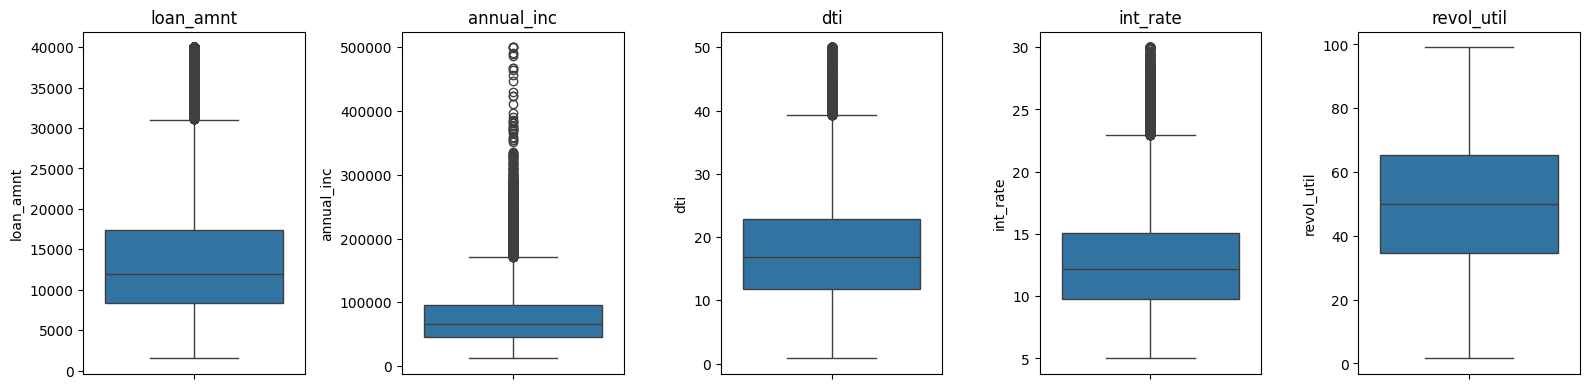

In [13]:
df.isna().mean().sort_values(ascending=False).head(10) # le taux de manquants par colonne
cols_num = ["loan_amnt", "annual_inc", "dti", "int_rate", "revol_util"]

fig, axes = plt.subplots(1, len(cols_num), figsize=(16,4))
for ax, col in zip(axes, cols_num):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [9]:
counts = df["loan_status"].value_counts(normalize=True)
counts

loan_status
Fully Paid     0.816125
Charged Off    0.183875
Name: proportion, dtype: float64

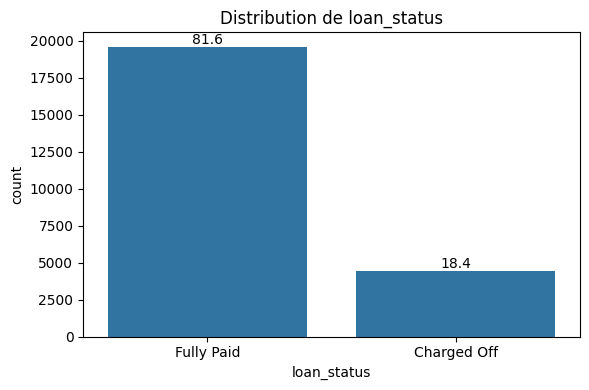

In [11]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x="loan_status", data=df, ax=ax)
ax.set_title("Distribution de loan_status")

total = len(df)
for p in ax.patches:
    pct = f"{100 * p.get_height() / total:.1f}"
    ax.annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 3. Préparation et split

Split stratifié, `random_state=42`.

## 4. Entraînement + benchmark

Au moins 2 jeux d'hyperparamètres. Trace chaque run dans `../experiments.md`.

## 4bis. Le score est-il stable ?

> Avant de comparer deux modèles ou de défendre un chiffre devant Pyrenex, vérifie une chose : **est-ce que ton F1 dépend du découpage train/test ?** Si le score varie déjà beaucoup en changeant juste la `random_state` du split, un gain de +0.005 entre deux modèles est probablement du bruit, pas un vrai progrès.

Lance la boucle ci-dessous avec le modèle entraîné en section 4. Si l'écart entre seeds dépasse l'écart entre tes deux jeux d'hyperparamètres, il faudra passer à la validation croisée (qu'on verra en M2).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# TODO : adapte aux noms de tes variables (X, y, et le modèle de la section 4)
scores = []
for seed in [0, 1, 42, 100, 2024]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    model = ...  # ré-instancie le même modèle qu'en section 4
    model.fit(X_tr, y_tr)
    f1 = f1_score(y_te, model.predict(X_te), average='macro')
    scores.append(f1)
    print(f"seed={seed:>4} → F1 macro = {f1:.3f}")

print(f"\nÉcart min-max : {max(scores) - min(scores):.3f}")

**Interprétation** :
- Écart min-max < 0.01 → ton score est stable, tu peux comparer deux modèles sereinement.
- Écart min-max > 0.02 → tes scores sont bruités par le découpage. Un gain inférieur à cet écart entre deux modèles n'est **pas significatif**, c'est probablement de la chance.

> Pour aller plus loin (on verra en M2) : `cross_val_score` fait ce travail proprement en 1 ligne, sur k folds, et te donne moyenne ± écart-type.

## 5. Évaluation sur holdout

F1 macro, F1 défaut, ROC-AUC, matrice de confusion, classification report.

## 6. Verdict

Synthèse à recopier dans `../verdict.md`.

## ⭐ Mission étoile optionnelle

Variante A : Gradient Boosting + SHAP. Variante B : Fine-tuning SLM sur `purpose`.